<a href="https://colab.research.google.com/github/abiramisivasubramaniam/CO2-Emission-Prediction/blob/main/Bank_Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Bank Customer Churn Prediction.csv")

print(df.head())

   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  


In [ ]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (10000, 12)

Column Names:
['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']

Data Types:
customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

Missing Values:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Duplicate Rows: 0

Statistical Summary:
        customer_id  credit_score           age        tenure        balance  \
count  1.000000e+04

In [ ]:
# Check the distribution of the target variable

print("Churn Value Counts:")
print(df['churn'].value_counts())

print("\nChurn Percentage:")
print(df['churn'].value_counts(normalize=True) * 100)

Churn Value Counts:
churn
0    7963
1    2037
Name: count, dtype: int64

Churn Percentage:
churn
0    79.63
1    20.37
Name: proportion, dtype: float64


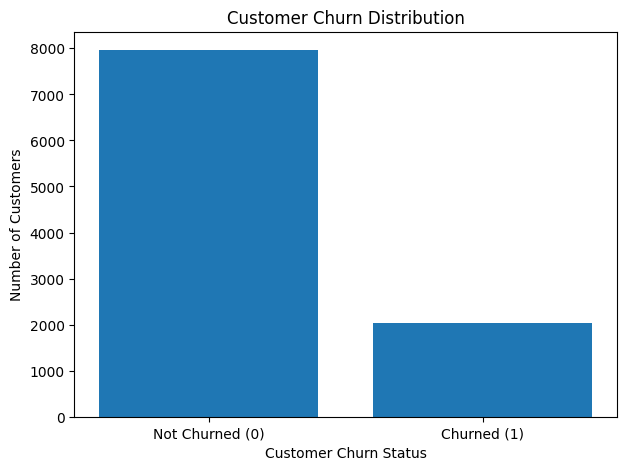

In [ ]:
import matplotlib.pyplot as plt

# Count of churn vs non-churn customers
churn_counts = df['churn'].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(['Not Churned (0)', 'Churned (1)'], churn_counts.values)

plt.xlabel("Customer Churn Status")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")

plt.show()

/tmp/ipykernel_1962/1898566373.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


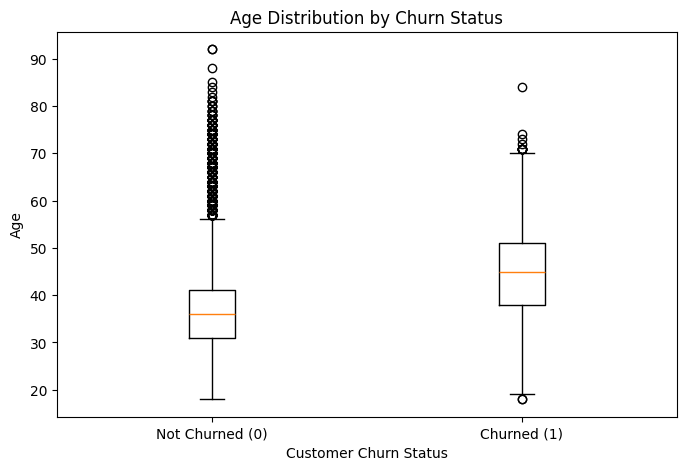

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df['churn'] == 0]['age'],
        df[df['churn'] == 1]['age']
    ],
    labels=['Not Churned (0)', 'Churned (1)']
)

plt.xlabel("Customer Churn Status")
plt.ylabel("Age")
plt.title("Age Distribution by Churn Status")

plt.show()

/tmp/ipykernel_1962/1708986383.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


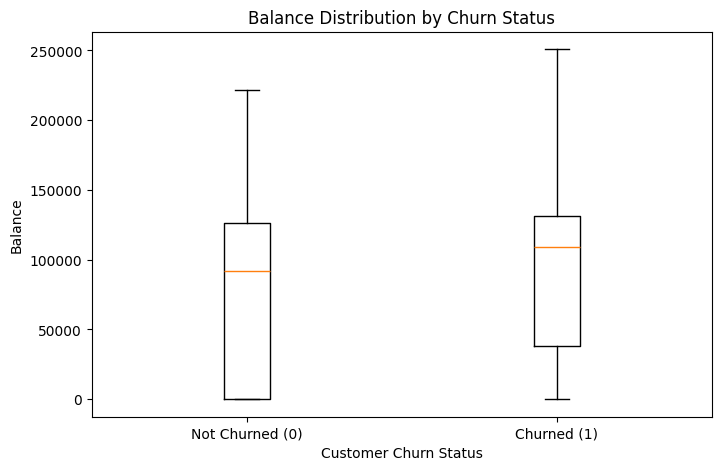

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df['churn'] == 0]['balance'],
        df[df['churn'] == 1]['balance']
    ],
    labels=['Not Churned (0)', 'Churned (1)']
)

plt.xlabel("Customer Churn Status")
plt.ylabel("Balance")
plt.title("Balance Distribution by Churn Status")

plt.show()

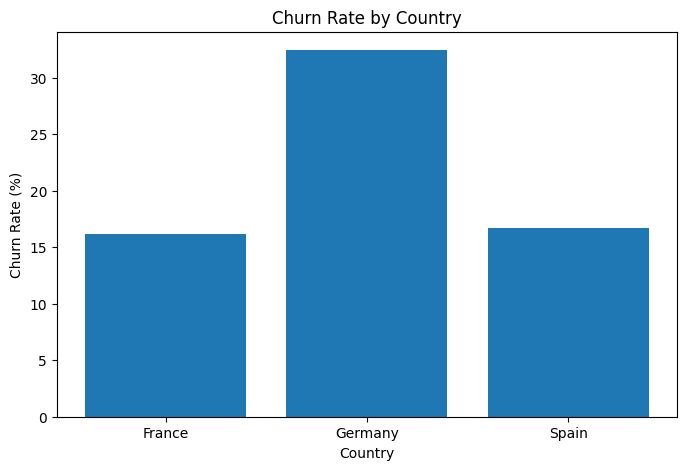

In [ ]:
import matplotlib.pyplot as plt

# Calculate churn rate by country
country_churn = df.groupby('country')['churn'].mean() * 100

plt.figure(figsize=(8, 5))

plt.bar(country_churn.index, country_churn.values)

plt.xlabel("Country")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Country")

plt.show()

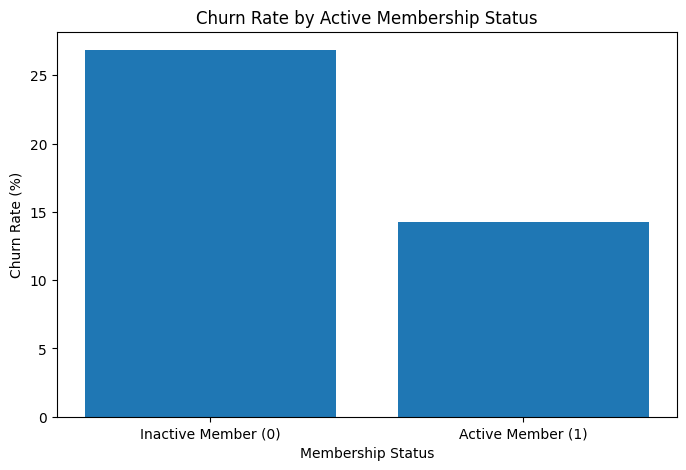

In [ ]:
import matplotlib.pyplot as plt

# Calculate churn rate by active member status
active_churn = df.groupby('active_member')['churn'].mean() * 100

plt.figure(figsize=(8, 5))

plt.bar(
    ['Inactive Member (0)', 'Active Member (1)'],
    active_churn.values
)

plt.xlabel("Membership Status")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Active Membership Status")

plt.show()

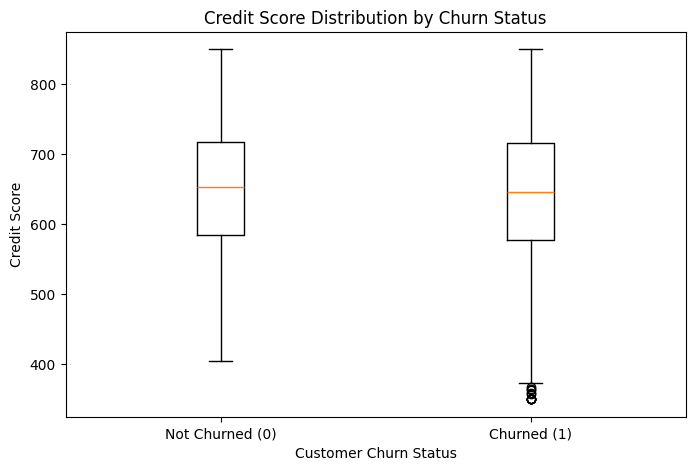

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df['churn'] == 0]['credit_score'],
        df[df['churn'] == 1]['credit_score']
    ],
    tick_labels=['Not Churned (0)', 'Churned (1)']
)

plt.xlabel("Customer Churn Status")
plt.ylabel("Credit Score")
plt.title("Credit Score Distribution by Churn Status")

plt.show()

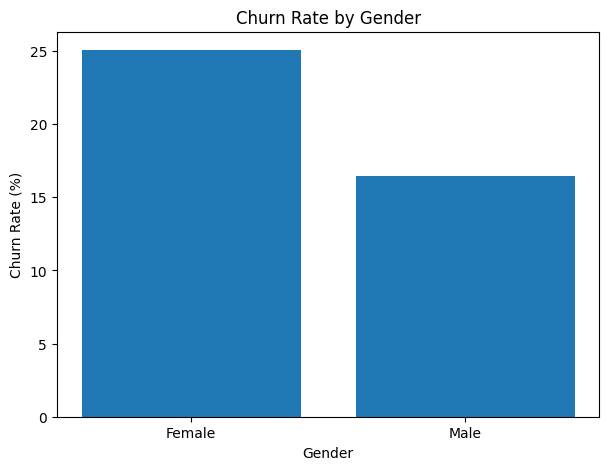

gender
Female    25.071539
Male      16.455928
Name: churn, dtype: float64


In [ ]:
# Calculate churn rate by gender
gender_churn = df.groupby('gender')['churn'].mean() * 100

plt.figure(figsize=(7, 5))

plt.bar(gender_churn.index, gender_churn.values)

plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Gender")

plt.show()

print(gender_churn)

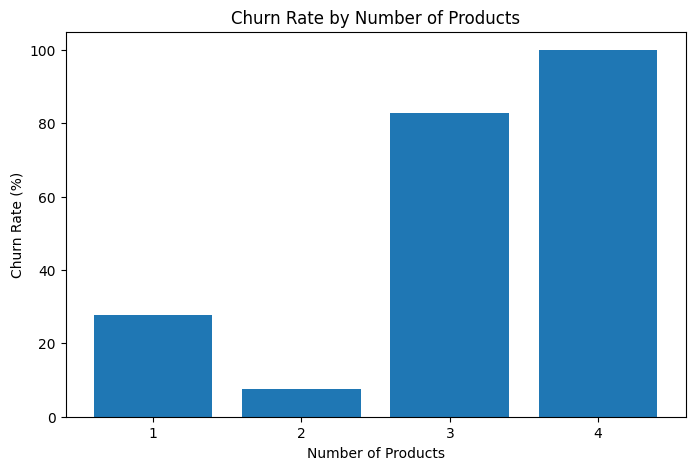

products_number
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: churn, dtype: float64


In [ ]:
# Calculate churn rate by number of products
products_churn = df.groupby('products_number')['churn'].mean() * 100

plt.figure(figsize=(8, 5))

plt.bar(
    products_churn.index.astype(str),
    products_churn.values
)

plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Number of Products")

plt.show()

print(products_churn)

In [ ]:
print(df['products_number'].value_counts().sort_index())

products_number
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


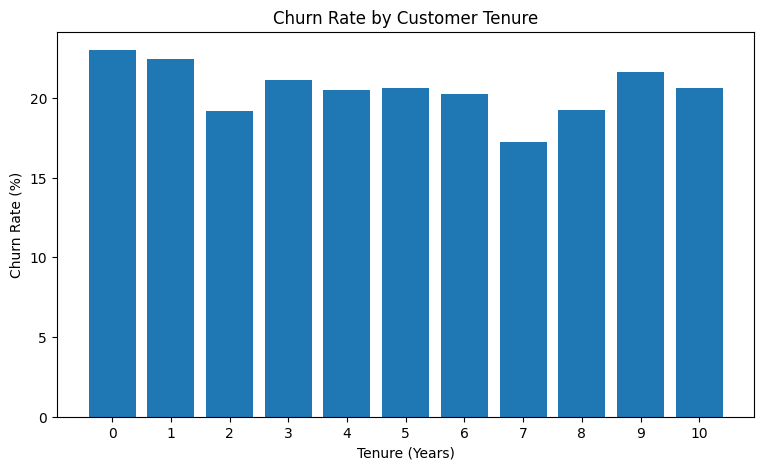

tenure
0     23.002421
1     22.415459
2     19.179389
3     21.110010
4     20.525784
5     20.652174
6     20.268873
7     17.217899
8     19.219512
9     21.646341
10    20.612245
Name: churn, dtype: float64


In [ ]:
# Calculate churn rate by tenure
tenure_churn = df.groupby('tenure')['churn'].mean() * 100

plt.figure(figsize=(9, 5))

plt.bar(
    tenure_churn.index.astype(str),
    tenure_churn.values
)

plt.xlabel("Tenure (Years)")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Customer Tenure")

plt.show()

print(tenure_churn)

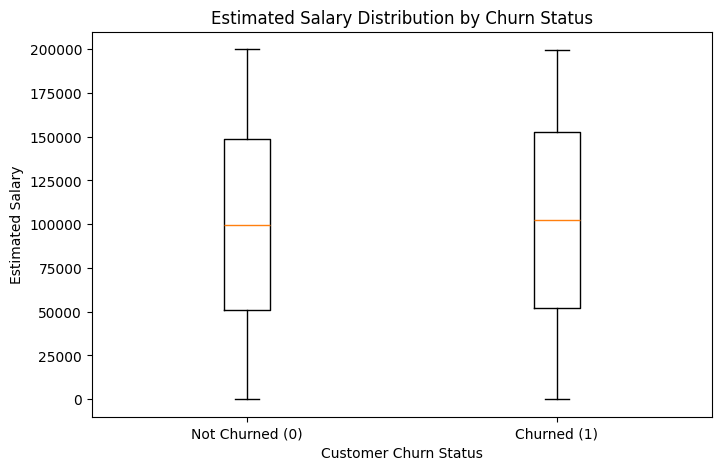

In [ ]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df['churn'] == 0]['estimated_salary'],
        df[df['churn'] == 1]['estimated_salary']
    ],
    tick_labels=['Not Churned (0)', 'Churned (1)']
)

plt.xlabel("Customer Churn Status")
plt.ylabel("Estimated Salary")
plt.title("Estimated Salary Distribution by Churn Status")

plt.show()

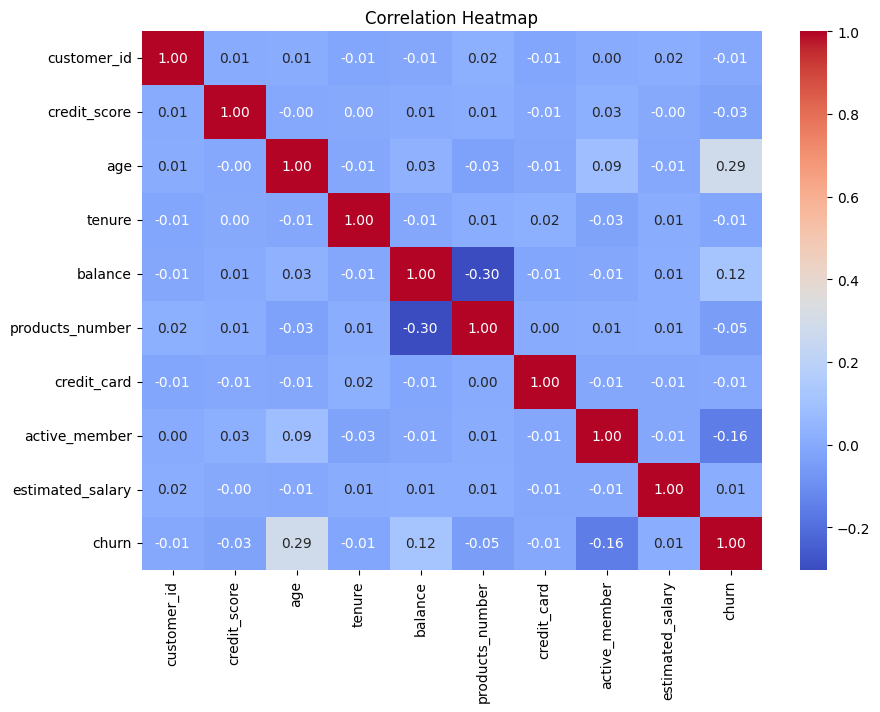

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# Create a copy of the dataset
df_model = df.copy()

# Remove customer ID because it is only an identifier
df_model = df_model.drop('customer_id', axis=1)

# Convert categorical variables into numerical variables
df_model = pd.get_dummies(
    df_model,
    columns=['country', 'gender'],
    drop_first=True
)

# Separate features and target
X = df_model.drop('churn', axis=1)
y = df_model['churn']

print("Features:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'country_Germany', 'country_Spain', 'gender_Male']

Feature shape: (10000, 11)
Target shape: (10000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (8000, 11)
Testing data: (2000, 11)
Training target: (8000,)
Testing target: (2000,)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create a pipeline with scaling and Logistic Regression
model = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(max_iter=1000))
])

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions made successfully!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions made successfully!
First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Get prediction probabilities for ROC-AUC
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression Evaluation Results")
print("--------------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)
print("ROC-AUC  :", roc_auc)

Logistic Regression Evaluation Results
--------------------------------------
Accuracy : 0.808
Precision: 0.5891472868217055
Recall   : 0.18673218673218672
F1-Score : 0.2835820895522388
ROC-AUC  : 0.7747778595236223


Confusion Matrix:
[[1540   53]
 [ 331   76]]


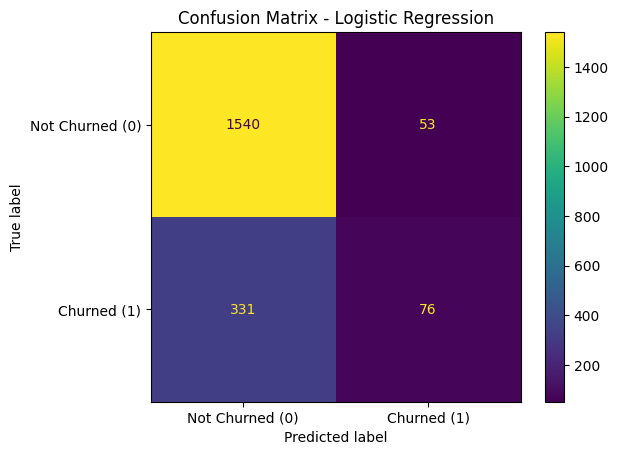

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Churned (0)', 'Churned (1)']
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

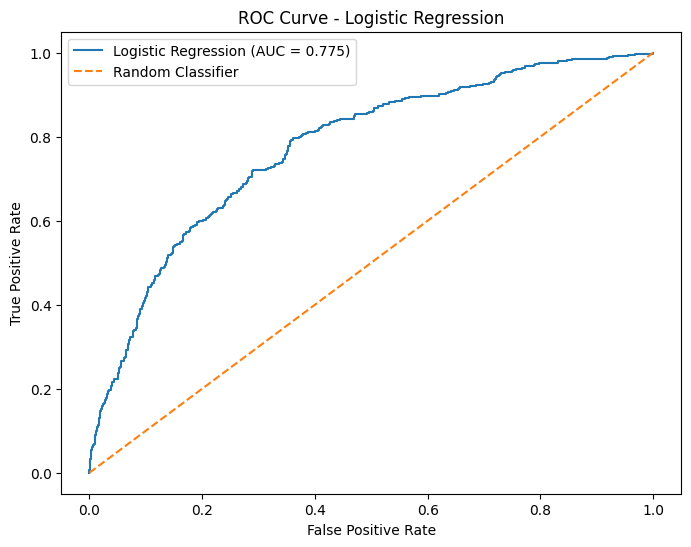

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {roc_auc:.3f})'
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()